<font>
<div dir=ltr align=center>
<img src='https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png' width=150 height=150> <br>
<font color=0F5298 size=7>
Artificial Intelligence <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2024<br>
<font color=3C99D size=5>
Practical Assignment 5 - V-Value and Q-Value Calculation <br>
<font color=696880 size=4>
Amir Mohammad Fakhimi


# Personal Data

In [1]:
student_number = "401102789"
First_Name = "Seyed Ali"
Last_Name = "Vakilzadeh"

# Objectives
This assignment will guide you through:
1. Implementing V-value and Q-value calculation on an $(n_{row} \times n_{col})$ grid.
2. Verifying the equivalence of $V(s)$ and $Q(s, a)$ using the Bellman equations.
3. Identifying the best action for each state based on Q-values.

# Libraries

In [2]:
import numpy as np
!pip install gymnasium
from gymnasium import Env, spaces
from enum import Enum
from typing import List, Tuple, Callable
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 8.4 MB/s eta 0:00:00


# Problem Definition
Consider an $(n_{row} \times n_{col})$ grid world where an agent can move in four directions: North, South, East, and West. The agent receives a reward for each state it visits, and the goal is to find the optimal policy that maximizes the total reward. The grid world has the following properties:
- The agent receives a living reward of $living_reward$ for each non-terminal state.
- The positive terminal state has a reward of $positive_terminal_reward$.
- The negative terminal state has a reward of $negative_terminal_reward$.
- The agent cannot move into walls (specified by coordinates).
- The discount factor for future rewards is $gamma$.
- The agent can move to the next state with a probability of 1. In other words, the environment is deterministic without any noise.

In [3]:
# Actions: North, South, East, West
class Action(Enum):
    N = 0
    S = 1
    E = 2
    W = 3


# Utility to map Action -> (delta_row, delta_col)
ACTION_DELTAS = {
    Action.N: (-1, 0),
    Action.S: (1, 0),
    Action.E: (0, 1),
    Action.W: (0, -1),
}

# A dictionary to map action to arrow symbols
ACTION_TO_ARROW = {
    Action.N: '↑',
    Action.S: '↓',
    Action.E: '→',
    Action.W: '←',
}

In [5]:
class GridEnv(Env):
    """
    A customizable Grid Environment following the Gymnasium interface.

    Args:
        n_row (int): Number of rows.
        n_col (int): Number of columns.
        positive_terminal (tuple[int,int]): Coordinates of the positive terminal state.
        negative_terminal (tuple[int,int]): Coordinates of the negative terminal state.
        positive_terminal_reward (float): Reward for the positive terminal state.
        negative_terminal_reward (float): Reward for the negative terminal state.
        walls (set[tuple[int,int]]): Set of impassable wall coordinates.
        living_reward (float): The reward for all non-terminal states.

    Observations:
        - Flattened state index in [0, n_row*n_col - 1].

    Actions:
        - Discrete(4) -> [N=0, S=1, E=2, W=3].
    """

    metadata = {'render_modes': ['human']}

    def __init__(
            self,
            n_row=6,
            n_col=5,
            positive_terminal=(2, 3),
            negative_terminal=(3, 2),
            positive_terminal_reward=1.0,
            negative_terminal_reward=-1.0,
            walls=None,
            living_reward=-0.04
    ):
        super().__init__()

        # Store configuration
        self.n_row = n_row
        self.n_col = n_col
        self.POSITIVE_TERMINAL = positive_terminal
        self.NEGATIVE_TERMINAL = negative_terminal
        self.WALLS = walls if walls is not None else set()

        # Initialize the reward matrix
        self.rewards = np.full((self.n_row, self.n_col), living_reward, dtype=np.float32)
        self.rewards[self.POSITIVE_TERMINAL] = positive_terminal_reward
        self.rewards[self.NEGATIVE_TERMINAL] = negative_terminal_reward

        # Define observation space (single integer in [0, n_row*n_col - 1])
        self.observation_space = spaces.Discrete(self.n_row * self.n_col)

        # Define action space (4 discrete actions)
        self.action_space = spaces.Discrete(len(Action))

        # Internal state: (row, col)
        self.state = None

    def reset(self, seed=None, options=None):
        """
        Resets the environment to a valid (row, col) that is not a wall or terminal.

        Args:
            - seed (int): Random seed for reproducibility.
            - options (dict): Additional options for the environment.

        Returns:
            - observation (int): Flattened initial state.
            - info (dict): Additional information.
        """
        super().reset(seed=seed)

        while True:
            row = self.np_random.integers(self.n_row)
            col = self.np_random.integers(self.n_col)

            # Must not be a terminal or wall
            if (row, col) != self.POSITIVE_TERMINAL and (row, col) != self.NEGATIVE_TERMINAL and (
                    row, col) not in self.WALLS:
                self.state = (row, col)
                break

        observation = self._get_observation()
        info = {}
        return observation, info

    def step(self, action):
        """
        Applies the given action in the current state.

        Args:
            - action (int): Action index in [0, 3].

        Returns:
          - observation (int): Flattened next-state
          - reward (float)
          - done (bool)
          - truncated (bool)
          - info (dict)
        """
        row, col = self.state

        # Convert the action integer to an Action enum
        action_enum = Action(action)
        d_row, d_col = ACTION_DELTAS[action_enum]

        # Compute next row/col
        next_row = max(0, min(self.n_row - 1, row + d_row))
        next_col = max(0, min(self.n_col - 1, col + d_col))

        # If it's a wall, stay where you are
        if (next_row, next_col) in self.WALLS:
            next_row, next_col = row, col

        # Compute reward and check if it’s terminal
        reward = self.rewards[next_row, next_col]
        done = (next_row, next_col) == self.POSITIVE_TERMINAL or (next_row, next_col) == self.NEGATIVE_TERMINAL

        # Update internal state
        self.state = (next_row, next_col)

        # No explicit time-limit: truncated = False
        truncated = False
        info = {}

        return self._get_observation(), float(reward), done, truncated, info

    def render(self, mode='human'):
        """
        Render the environment using matplotlib.

        Args:
            - mode (str): The rendering mode.
                - If mode='human', a window with the plot is shown.
                - If mode='rgb_array', this method returns a numpy array of shape (n_row, n_col, 3).

        Returns:
            - np.ndarray or None: The rendered image if mode='rgb_array'.
        """

        # Create an RGB image where each cell is one pixel.
        # Shape: (n_row, n_col, 3) for R, G, B channels
        rgb_image = np.zeros((self.n_row, self.n_col, 3), dtype=np.float32)

        # Define some colors in [0, 1] range (RGB)
        COLOR_WALL = (0.2, 0.2, 0.2)  # dark gray
        COLOR_POSITIVE = (0.0, 1.0, 0.0)  # green
        COLOR_NEGATIVE = (1.0, 0.0, 0.0)  # red
        COLOR_AGENT = (0.6, 0.0, 0.6)  # magenta
        COLOR_EMPTY = (1.0, 1.0, 1.0)  # white

        # Fill in the pixels
        for i in range(self.n_row):
            for j in range(self.n_col):
                if (i, j) in self.WALLS:
                    rgb_image[i, j] = COLOR_WALL
                elif (i, j) == self.POSITIVE_TERMINAL:
                    rgb_image[i, j] = COLOR_POSITIVE
                elif (i, j) == self.NEGATIVE_TERMINAL:
                    rgb_image[i, j] = COLOR_NEGATIVE
                elif (i, j) == self.state:
                    rgb_image[i, j] = COLOR_AGENT
                else:
                    rgb_image[i, j] = COLOR_EMPTY

        if mode == 'rgb_array':
            # Return the raw image array (e.g., to be used by a video recorder)
            return rgb_image

        elif mode == 'human':
            # Show using matplotlib
            plt.figure('GridEnv')
            plt.clf()  # clear figure

            # Display the image
            plt.imshow(rgb_image, origin='upper', interpolation='nearest')
            plt.title('Grid Environment')

            # Optionally draw grid lines
            # Minor ticks at cell boundaries
            plt.xticks(np.arange(-0.5, self.n_col, 1))
            plt.yticks(np.arange(-0.5, self.n_row, 1))
            plt.grid(color='black', linestyle='-', linewidth=1, which='major')

            # Pause briefly so the figure updates
            plt.pause(0.001)
        else:
            raise ValueError(f'Unsupported render mode: {mode}')

    def close(self):
        pass

    def _get_observation(self):
        """
        Returns the flattened state index.

        Returns:
            int: Flattened state index.
        """
        row, column = self.state
        return row * self.n_col + column

# V-Value and Q-Value Calculation
This part involves implementing the value iteration algorithm. This algorithm calculates the optimal state values $V(s)$ by iteratively applying the Bellman update equation.

In [6]:
def next_position(env: GridEnv, i, j, action: Action):
    """
    Predict the next position from (i, j) given an Action,
    mirroring the environment's transition logic without changing its state.
    if new position is a wall, remain where you are.

    Args:
        - env (GridEnv): The grid environment.
        - i (int): Current row.
        - j (int): Current column.
        - action (Action): Action to take.

    Returns:
        - next_i (int): Next row.
        - next_j (int): Next column.
    """
     # Calculate deltas for the action
    di, dj = ACTION_DELTAS[action]

    # Compute potential next position
    next_i = max(0, min(env.n_row - 1, i + di))
    next_j = max(0, min(env.n_col - 1, j + dj))

    # Check if the new position is a wall
    if (next_i, next_j) in env.WALLS:
        # Stay in the current position if it's a wall
        next_i, next_j = i, j

    return next_i, next_j

## Calculating V-values

In [8]:
def value_iteration(env: GridEnv, gamma: float = 0.9, epsilon: float = 1e-6, max_iterations: int = 1000):
    """
    Perform value iteration until convergence (delta < epsilon).

    Args:
        - env (GridEnv): The grid environment.
        - gamma (float): Discount factor.
        - epsilon (float): Stopping criterion.
        - max_iterations (int): Safety bound on the number of iterations.

    Returns:
        - V (np.ndarray): (n_row, n_col) array of state values.
        - final_iteration (int): The last iteration number (starting from 1).
        - history (List[np.ndarray]): List of V-value snapshots.
    """
    n_row, n_col = env.n_row, env.n_col
    V = np.zeros((n_row, n_col), dtype=np.float32)
    history = []

    for iteration in range(max_iterations):
        delta = 0  # Track the maximum change in V for convergence
        new_V = np.copy(V)

        # Iterate over all states
        for i in range(n_row):
            for j in range(n_col):
                if (i, j) in env.WALLS or (i, j) in [env.POSITIVE_TERMINAL, env.NEGATIVE_TERMINAL]:
                    continue

                action_values = []
                for action in Action:
                    next_i, next_j = next_position(env, i, j, action)
                    reward = env.rewards[next_i, next_j]
                    action_value = reward + gamma * V[next_i, next_j]
                    action_values.append(action_value)

                new_V[i, j] = max(action_values)
                delta = max(delta, abs(new_V[i, j] - V[i, j]))

        history.append(new_V)

        V = new_V

        # Check for convergence
        if delta < epsilon:
            return V, iteration + 1, history

    return V, max_iterations, history


## Calculating Q-values
Calculate the Q-values for each state-action pair **without using V-values**.

In [11]:
def q_iteration(env: GridEnv, gamma: float = 0.9, epsilon: float = 1e-6, max_iterations: int = 1000):
    """
    Perform Q-value iteration until convergence (delta < epsilon).

    Args:
        - env (GridEnv): The grid environment.
        - gamma (float): Discount factor.
        - epsilon (float): Stopping criterion.
        - max_iterations (int): Safety bound on the number of iterations.

    Returns:
        - Q (np.ndarray): Q-values of shape (n_row, n_col, num_actions).
        - final_iteration (int): The last iteration number (starting from 1).
        - history (List[np.ndarray]): List of Q-value snapshots.
    """
    n_row, n_col = env.n_row, env.n_col
    num_actions = len(Action)

    Q = np.zeros((n_row, n_col, num_actions), dtype=np.float32)
    history = []

    for iteration in range(max_iterations):
        delta = 0  # Track the maximum change in Q-values for convergence
        new_Q = np.copy(Q)  # Initialize a new Q array for this iteration

        # Iterate over all states
        for i in range(n_row):
            for j in range(n_col):
                # Skip terminal and wall states
                if (i, j) in env.WALLS or (i, j) in [env.POSITIVE_TERMINAL, env.NEGATIVE_TERMINAL]:
                    continue

                for action in Action:
                    next_i, next_j = next_position(env, i, j, action)
                    reward = env.rewards[next_i, next_j]

                    next_q_values = [Q[next_i, next_j, a.value] for a in Action]
                    new_Q[i, j, action.value] = reward + gamma * max(next_q_values)

                    delta = max(delta, abs(new_Q[i, j, action.value] - Q[i, j, action.value]))

        history.append(new_Q)

        Q = new_Q

        if delta < epsilon:
            return Q, iteration + 1, history

    return Q, max_iterations, history


# Calculations

In [10]:
gamma = 0.9
epsilon = 1e-6
max_iterations = 1000

In [12]:
n_row = 6
n_col = 5
positive_terminal = (2, 3)
negative_terminal = (3, 2)
walls = {(1, 1), (2, 2), (3, 3)}
living_reward = -0.04

In [13]:
env = GridEnv(
    n_row=n_row,
    n_col=n_col,
    positive_terminal=positive_terminal,
    negative_terminal=negative_terminal,
    walls=walls,
    living_reward=living_reward
)

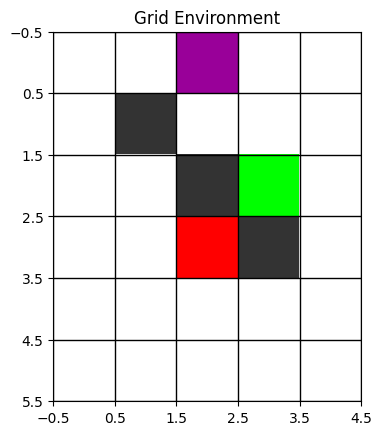

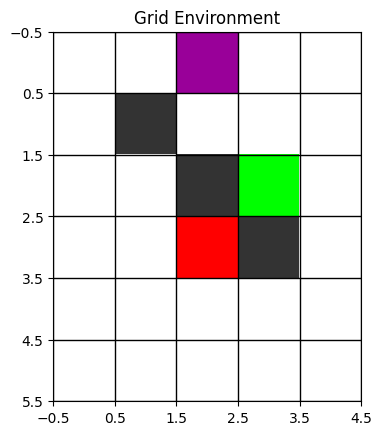

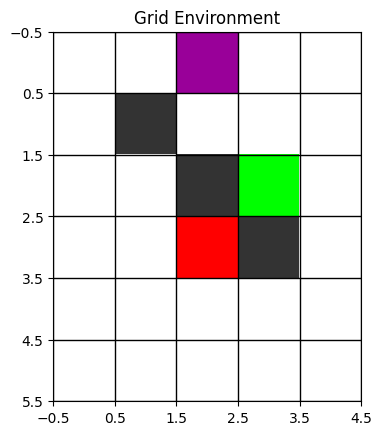

In [27]:
# Run a short random episode to visualize the environment
# Here render method will be called

obs, info = env.reset()
for _ in range(3):
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    env.render()
    if done or truncated:
        print('Episode finished!')
        obs, info = env.reset()

In [16]:
V, V_iteration, V_history = value_iteration(env, gamma=gamma, epsilon=epsilon, max_iterations=max_iterations)

In [28]:
print('Final V-values:')
print(V)

Final V-values:
[[0.51854    0.62060004 0.734      0.86       0.734     ]
 [0.42668602 0.         0.86       1.         0.86      ]
 [0.34401742 0.26961568 0.         0.         1.        ]
 [0.26961568 0.34401742 0.         0.         0.86      ]
 [0.34401742 0.42668602 0.51854    0.62060004 0.734     ]
 [0.26961568 0.34401742 0.42668602 0.51854    0.62060004]]


In [29]:
Q, Q_iteration, Q_history = q_iteration(env, gamma=gamma, epsilon=epsilon, max_iterations=max_iterations)

In [30]:
print('Final Q-values:')
print(Q)

Final Q-values:
[[[ 0.42668602  0.34401742  0.51854     0.42668602]
  [ 0.51854     0.51854     0.62060004  0.42668602]
  [ 0.62060004  0.734       0.734       0.51854   ]
  [ 0.734       0.86        0.62060004  0.62060004]
  [ 0.62060004  0.734       0.62060004  0.734     ]]

 [[ 0.42668602  0.26961568  0.34401742  0.34401742]
  [ 0.          0.          0.          0.        ]
  [ 0.62060004  0.734       0.86        0.734     ]
  [ 0.734       1.          0.734       0.734     ]
  [ 0.62060004  0.86        0.734       0.86      ]]

 [[ 0.34401742  0.20265411  0.20265411  0.26961568]
  [ 0.20265411  0.26961568  0.20265411  0.26961568]
  [ 0.          0.          0.          0.        ]
  [ 0.          0.          0.          0.        ]
  [ 0.734       0.734       0.86        1.        ]]

 [[ 0.26961568  0.26961568  0.26961568  0.20265411]
  [ 0.20265411  0.34401742 -1.          0.20265411]
  [ 0.          0.          0.          0.        ]
  [ 0.          0.          0.          0.

# Verification
This part verifies that the state values $V(s)$ and Q-values $Q(s, a)$ satisfy the Bellman equations.

In [31]:
def verify_bellman_equations(env: GridEnv, V: np.ndarray, Q: np.ndarray):
    """
    Verifies the Bellman equations for V-values and Q-values:
    Checks that V(s) = max_a Q(s, a) for each non-terminal, non-wall state.

    Args:
        - env (GridEnv): The grid environment.
        - V (np.ndarray): State values of shape (n_row, n_col).
        - Q (np.ndarray): Q-values of shape (n_row, n_col, num_actions).

    Returns:
        None
    """
    for i in range(env.n_row):
        for j in range(env.n_col):
            # skip walls and terminal states
            if (i, j) in env.WALLS:
                continue
            if (i, j) == env.POSITIVE_TERMINAL or (i, j) == env.NEGATIVE_TERMINAL:
                continue

            v_value = V[i, j]
            max_q = np.max(Q[i, j, :])
            assert np.isclose(v_value, max_q), (
                f'Bellman verification failed at ({i}, {j}): '
                f'V={v_value} vs. max_a Q={max_q}'
            )

    print('Verification passed: V(s) = max_a Q(s, a) for all valid states.')

In [32]:
verify_bellman_equations(env, V, Q)

Verification passed: V(s) = max_a Q(s, a) for all valid states.


# Find the Optimal Policy
This part finds the best action for each state based on Q-values.

In [34]:
def get_optimal_policy_indices(env: GridEnv, Q: np.ndarray):
    """
    Extracts the optimal policy (action indices) from Q-values.

    Args:
        - env (GridEnv): The GridEnv (with env.n_row, env.n_col, env.WALLS, etc.).
        - Q (np.ndarray): A 3D array of shape (n_row, n_col, num_actions) with Q-values.

    Returns:
        - policy_indices (np.ndarray):
            A 2D array of shape (n_row, n_col). Each cell contains:
              - The best action index [0, 3] for normal states;
              - -1 for walls or terminal states.
    """
    n_row, n_col, num_actions = Q.shape
    policy_indices = np.full((n_row, n_col), -1, dtype=int)  # Initialize with -1 for walls and terminal states

    for i in range(n_row):
        for j in range(n_col):
            if (i, j) in env.WALLS or (i, j) in [env.POSITIVE_TERMINAL, env.NEGATIVE_TERMINAL]:
                continue

            policy_indices[i, j] = np.argmax(Q[i, j])

    return policy_indices


In [35]:
def get_policy_arrows(env: GridEnv, policy_indices: np.ndarray):
    """
    Converts policy indices into a 2D array of symbols:
      - Walls -> '#'
      - Positive terminal -> '+'
      - Negative terminal -> '-'
      - Normal states -> one of { '↑','↓','→','←' }.

    Args:
        - env: The GridEnv (with env.n_row, env.n_col, env.WALLS, etc.).
        - policy_indices (np.ndarray): 2D array (n_row, n_col) with best action or -1.

    Returns:
        policy_arrows (np.ndarray): 2D array (n_row, n_col) of strings.
    """
    n_row, n_col = policy_indices.shape
    policy_arrows = np.full((n_row, n_col), '', dtype=object)

    for i in range(n_row):
        for j in range(n_col):
            # Check if it's a wall or terminal by indexing -1 or checking env
            if policy_indices[i, j] == -1:
                if (i, j) in env.WALLS:
                    policy_arrows[i, j] = '#'
                elif (i, j) == env.POSITIVE_TERMINAL:
                    policy_arrows[i, j] = '+'
                elif (i, j) == env.NEGATIVE_TERMINAL:
                    policy_arrows[i, j] = '-'
                else:
                    # If -1 but not a known special cell, just leave blank or mark as '?'
                    policy_arrows[i, j] = '?'
            else:
                # Normal state: map to arrow
                best_action = policy_indices[i, j]
                policy_arrows[i, j] = ACTION_TO_ARROW.get(Action(best_action), '?')

    return policy_arrows


In [36]:
optimal_policy_indices = get_optimal_policy_indices(env, Q)
optimal_policy = get_policy_arrows(env, optimal_policy_indices)

In [37]:
print('Optimal Policy:')
print(optimal_policy)

Optimal Policy:
[['→' '→' '↓' '↓' '↓']
 ['↑' '#' '→' '↓' '↓']
 ['↑' '↓' '#' '+' '←']
 ['↑' '↓' '-' '#' '↑']
 ['→' '→' '→' '→' '↑']
 ['↑' '↑' '↑' '↑' '↑']]


# Visualization

## V-values with Optimal Policy

In [38]:
def plot_v_values(env: GridEnv, ax: matplotlib.axes.Axes, V: np.ndarray, optimal_policy: np.ndarray = None,
                  iteration_label='Final', add_colorbar: bool = True):
    """
    Visualizes the state values (V) on a grid, overlaying:
    - Numeric values of V
    - An arrow for the optimal policy of each state (if provided in optimal_policy)
    - Special colors/labels for walls and terminal states

    Args:
        - env (GridEnv): The grid environment (accessing env.n_row, env.n_col, env.WALLS, etc.).
        - ax (matplotlib.axes.Axes): Matplotlib axis to plot on.
        - V (np.ndarray): A 2D array of shape (n_row, n_col) containing V-values.
        - optimal_policy (np.ndarray): A 2D array of shape (n_row, n_col) with the optimal policy index per cell
                                   (0=Up, 1=Down, 2=Right, 3=Left).
                                   If None, no action arrows are displayed.
        - iteration_label (str or int): Displayed in the title (e.g., '20' or 'Converged').
        - add_colorbar (bool): Whether to add a colorbar to the plot.

    Returns:
        None
    """
    ax.set_title(f'V-values with Optimal Policy ({iteration_label})', fontsize=14)
    n_row, n_col = V.shape
    cax = ax.imshow(V, cmap='viridis', interpolation='nearest', origin='upper')

    if add_colorbar:
        plt.colorbar(cax, ax=ax, label='V-value', shrink=0.8, aspect=30, pad=0.02)

    # Annotate each cell
    for i in range(n_row):
        for j in range(n_col):
            current_state = (i, j)
            value = V[i, j]

            # Determine if cell is a wall or terminal
            if current_state in env.WALLS:
                # Wall: Draw a gray rectangle or label
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color='gray', alpha=0.5))
                text_label = 'Wall'
            elif current_state == env.POSITIVE_TERMINAL:
                # Positive terminal (green)
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color='green', alpha=0.5))
                text_label = 'End\n(+)'
            elif current_state == env.NEGATIVE_TERMINAL:
                # Negative terminal (red)
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color='red', alpha=0.5))
                text_label = 'End\n(-)'
            else:
                # Normal cell
                if optimal_policy is not None:
                    # Map the best action index to an arrow
                    arrow_idx = optimal_policy[i, j]
                    arrow_symbol = ACTION_TO_ARROW.get(Action(arrow_idx), '')
                    text_label = f'{value:.2f}\n{arrow_symbol}'
                else:
                    # Just show the value if no best_actions
                    text_label = f'{value:.2f}'

            # Place the text in the center of the cell
            ax.text(j, i, text_label, ha='center', va='center', fontsize=9, color='black' if value >= 0 else 'white')

    # Adjust axis ticks and labels
    ax.set_xticks(range(n_col))
    ax.set_yticks(range(n_row))
    ax.set_xticklabels(range(n_col))
    ax.set_yticklabels(range(n_row))

    # Set limits so cells line up with ticks
    ax.set_xlim(-0.5, n_col - 0.5)
    ax.set_ylim(n_row - 0.5, -0.5)

    # ax.set_aspect('equal')

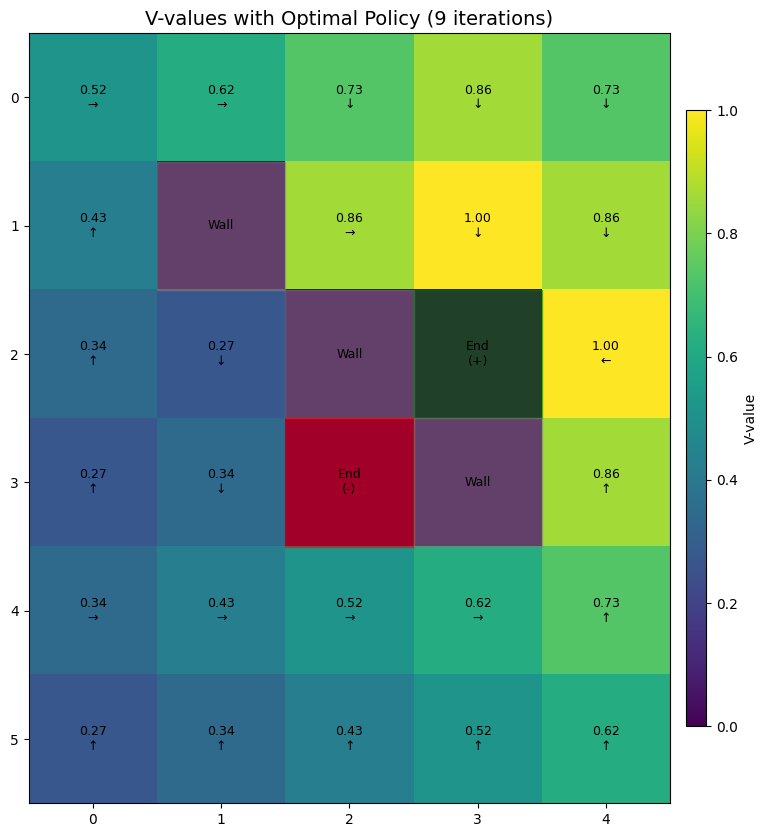

In [39]:
_, ax = plt.subplots(figsize=(10, 10))
plot_v_values(env, ax, V, optimal_policy=optimal_policy_indices, iteration_label=f'{V_iteration} iterations')
plt.show()

## Q-values with Optimal Policy

In [40]:
def plot_q_values(env: GridEnv, ax: matplotlib.axes.Axes, Q: np.ndarray, optimal_policy: np.ndarray = None,
                  iteration_label='Final', add_colorbar: bool = True):
    """
    Visualizes Q-values in each cell by dividing it into triangles
    (one triangle per action). The color of each triangle reflects Q(s,a).

    Walls and terminal states are highlighted separately.
    If optimal_policy is provided, an arrow is drawn indicating the optimal action.

    Args:
        - env (GridEnv): The grid environment (accessing env.n_row, env.n_col, env.WALLS, etc.).
        - ax (matplotlib.axes.Axes): The Matplotlib axis to draw on.
        - Q (np.ndarray): 3D array (n_row, n_col, num_actions) of Q-values.
        - optimal_policy (np.ndarray or None): 2D array (n_row, n_col) of optimal action indices (0..3).
        - iteration_label (str or int): Label for the plot title (e.g. '20', 'Converged', etc.).
        - add_colorbar (bool): Whether to add a colorbar legend.

    Returns:
        None
    """
    n_row, n_col, _ = Q.shape

    ax.set_xlim(-0.5, n_col - 0.5)
    ax.set_ylim(-0.5, n_row - 0.5)

    ax.set_title(f'Q-values with Optimal Policy ({iteration_label})', fontsize=14)

    # Define the 4 possible actions (consistent with Q's 3rd dimension)
    # and the triangle coordinates relative to cell center
    actions = [Action.N, Action.S, Action.E, Action.W]
    directions = {
        Action.N: [(0, 0), (-0.5, -0.5), (0.5, -0.5)],
        Action.S: [(0, 0), (-0.5, 0.5), (0.5, 0.5)],
        Action.E: [(0, 0), (0.5, -0.5), (0.5, 0.5)],
        Action.W: [(0, 0), (-0.5, -0.5), (-0.5, 0.5)]
    }

    # Create a color map for Q-values
    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin=Q.min(), vmax=Q.max())

    # For drawing the optimal policy arrow at the cell center
    arrow_positions = {
        Action.N: (0, -0.43),
        Action.S: (0, 0.43),
        Action.E: (0.35, 0.1),
        Action.W: (-0.35, 0.1)
    }

    for i in range(n_row):
        for j in range(n_col):
            current_state = (i, j)

            # Walls / Terminal states
            if current_state in env.WALLS:
                # Wall cell
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color='gray', alpha=0.5))
                ax.text(j, i, 'Wall', ha='center', va='center', fontsize=9, color='black')
                continue
            elif current_state == env.POSITIVE_TERMINAL:
                # Positive terminal (green)
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color='green', alpha=0.5))
                rew_str = f'{env.rewards[i, j]:.2f}'
                ax.text(j, i, f'{rew_str}\nPositive\nEnd', ha='center', va='center', fontsize=9, color='black')
                continue
            elif current_state == env.NEGATIVE_TERMINAL:
                # Negative terminal (red)
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color='red', alpha=0.5))
                rew_str = f'{env.rewards[i, j]:.2f}'
                ax.text(j, i, f'{rew_str}\nNegative\nEnd', ha='center', va='center', fontsize=9, color='white')
                continue

            # Normal cells: draw 4 triangles (one per action)
            for a_idx, action in enumerate(actions):
                q_value = Q[i, j, a_idx]

                # Build the triangle coords around (j, i) (the center of cell)
                tri_coords = [(j + x, i + y) for (x, y) in directions[action]]
                color = cmap(norm(q_value))

                # Draw the triangle
                polygon = plt.Polygon(tri_coords, closed=True, edgecolor='black', facecolor=color, alpha=0.8)
                ax.add_patch(polygon)

                # Place Q-value text near triangle center
                x_center = np.mean([x for x, _ in tri_coords])
                y_center = np.mean([y for _, y in tri_coords])
                ax.text(x_center, y_center, f'{q_value:.2f}', ha='center', va='center', fontsize=8,
                        color='black' if q_value >= 0 else 'white')

            # Draw best-action arrow, if provided
            if optimal_policy is not None:
                best_a_idx = optimal_policy[i, j]

                # If -1 => wall/terminal => skip
                if 0 <= best_a_idx < len(actions):
                    best_action = actions[best_a_idx]
                    dx, dy = arrow_positions[best_action]
                    arrow_char = ACTION_TO_ARROW.get(best_action, '?')

                    # The center of the cell is (j, i)
                    arrow_x = j + dx
                    arrow_y = i + dy
                    ax.text(arrow_x, arrow_y, arrow_char, ha='center', va='center', fontsize=10, color='blue')

    # Optional colorbar for Q-value scale
    if add_colorbar:
        plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Q-value', shrink=0.8, aspect=30,
                     pad=0.02)

    # Set up axis ticks
    ax.set_xticks(range(n_col))
    ax.set_yticks(range(n_row))
    ax.set_xticklabels(range(n_col))
    ax.set_yticklabels(range(n_row))

    ax.invert_yaxis()
    ax.set_aspect('equal')

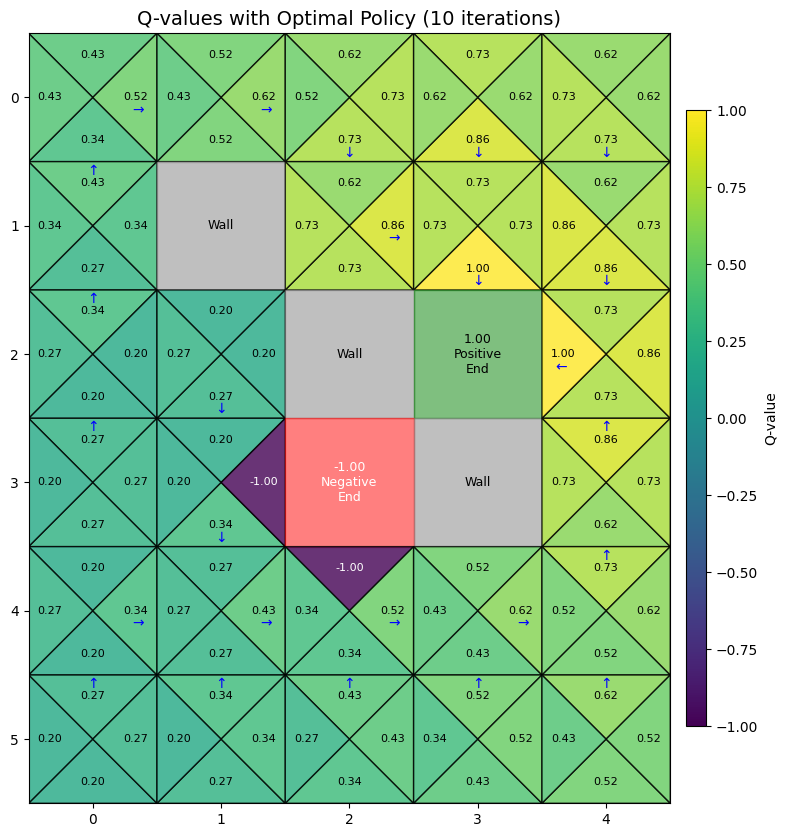

In [41]:
_, ax = plt.subplots(figsize=(10, 10))
plot_q_values(env, ax, Q, optimal_policy=optimal_policy_indices, iteration_label=f'{Q_iteration} iterations')
plt.show()

## Animated Visualization

In [42]:
def animated_visualization(env: GridEnv, history: List[np.ndarray], update_function: Callable, all_iterations: int,
                           save_title: str, fig_size: Tuple[int, int] = (10, 10)):
    """
    Creates an animation of V-value progression over iterations with optimal policy arrows.

    Args:
        env (GridEnv): The grid environment (accessing env.n_row, env.n_col, env.WALLS, etc.).
        history (List[np.ndarray]): History of V-values across iterations.
        update_function (function): Function to update the plot at each frame.
        all_iterations (int): Total number of iterations.
        save_title (str): Title of the file to save the animation (GIF format).
        fig_size (tuple[int, int]): Size of the figure (width, height).

    Returns:
        None
    """
    fig, ax = plt.subplots(figsize=fig_size)
    is_first = True

    def update(frame):
        nonlocal is_first

        ax.clear()
        update_function(env, ax, history[frame], None, f'{frame + 1}/{all_iterations}', add_colorbar=is_first)
        is_first = False

    ani = animation.FuncAnimation(fig, update, frames=len(history), repeat=True)
    ani.save(save_title, writer='pillow')
    plt.show()

### V-values Animation

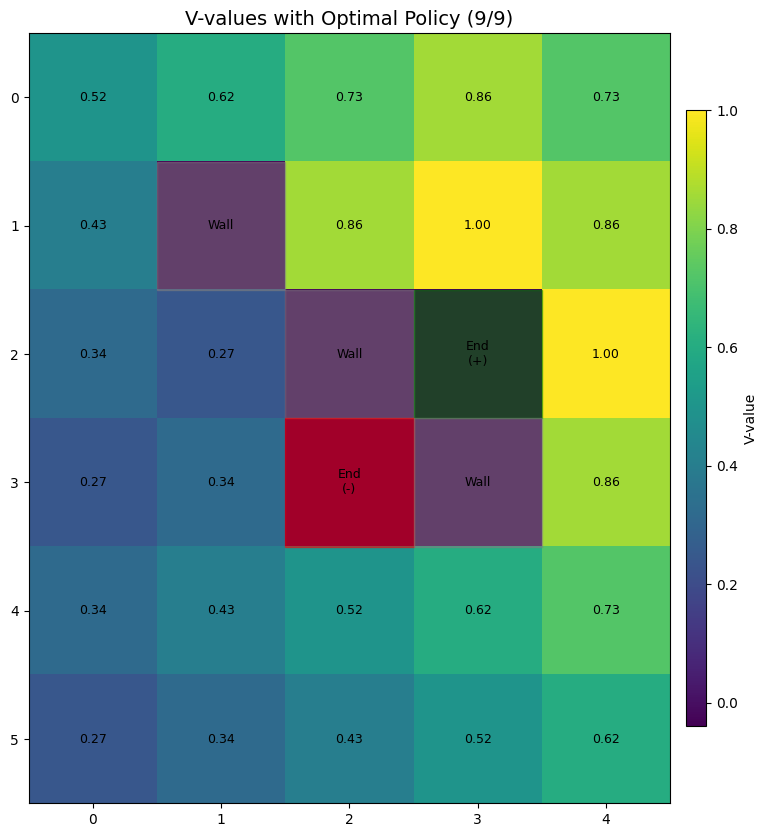

In [43]:
animated_visualization(env, V_history, plot_v_values, V_iteration, 'v_values_animation.gif')

### Q-values Animation

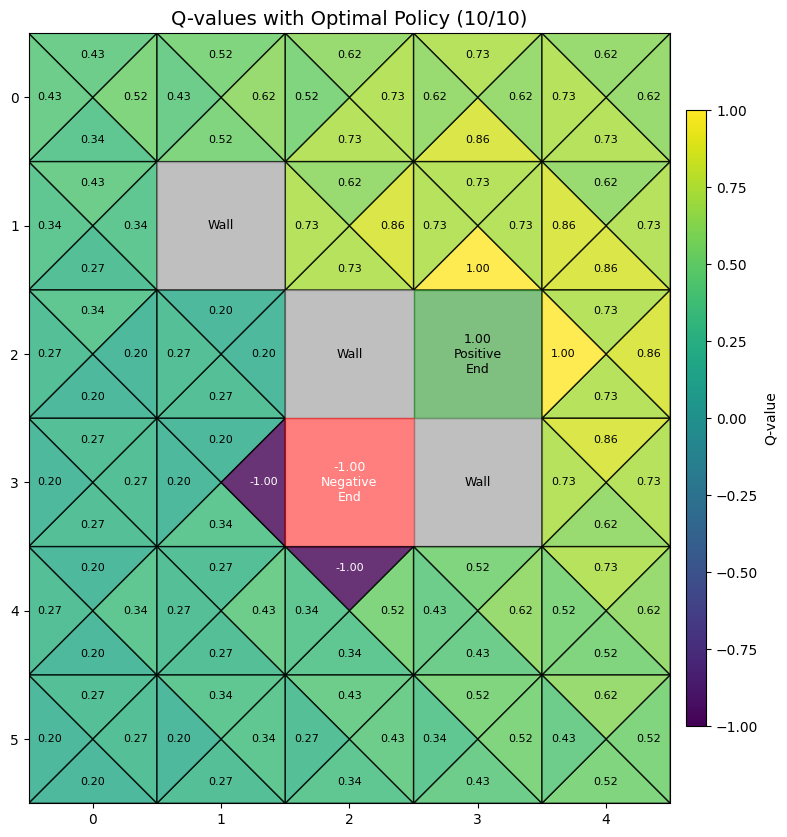

In [44]:
animated_visualization(env, Q_history, plot_q_values, Q_iteration, 'q_values_animation.gif')

# Test
**Output of each cell should be same as provided outputs.**

## Define new parameters

In [45]:
gamma = 0.95
epsilon = 1e-5
max_iterations = 100

In [46]:
n_row = 10
n_col = 11
positive_terminal = (7, 5)
negative_terminal = (4, 4)
walls = {(3, 3), (4, 3), (5, 3)}
living_reward = -0.06

In [47]:
env = GridEnv(
    n_row=n_row,
    n_col=n_col,
    positive_terminal=positive_terminal,
    negative_terminal=negative_terminal,
    walls=walls,
    living_reward=living_reward
)

## Calculations

In [48]:
V, V_iteration, V_history = value_iteration(env, gamma=gamma, epsilon=epsilon, max_iterations=max_iterations)

In [49]:
Q, Q_iteration, Q_history = q_iteration(env, gamma=gamma, epsilon=epsilon, max_iterations=max_iterations)

## Verification

In [50]:
verify_bellman_equations(env, V, Q)

Verification passed: V(s) = max_a Q(s, a) for all valid states.


## Find the Optimal Policy

In [51]:
optimal_policy_indices = get_optimal_policy_indices(env, Q)
optimal_policy = get_policy_arrows(env, optimal_policy_indices)

In [52]:
print('Optimal Policy:')
print(optimal_policy)

Optimal Policy:
[['↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓']
 ['↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓']
 ['↓' '↓' '↓' '→' '↓' '↓' '↓' '↓' '↓' '↓' '↓']
 ['↓' '↓' '↓' '#' '→' '↓' '↓' '↓' '↓' '↓' '↓']
 ['↓' '↓' '↓' '#' '-' '↓' '↓' '↓' '↓' '↓' '↓']
 ['↓' '↓' '↓' '#' '↓' '↓' '↓' '↓' '↓' '↓' '↓']
 ['↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓']
 ['→' '→' '→' '→' '→' '+' '←' '←' '←' '←' '←']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑']]


## Visualization

### V-values with Optimal Policy

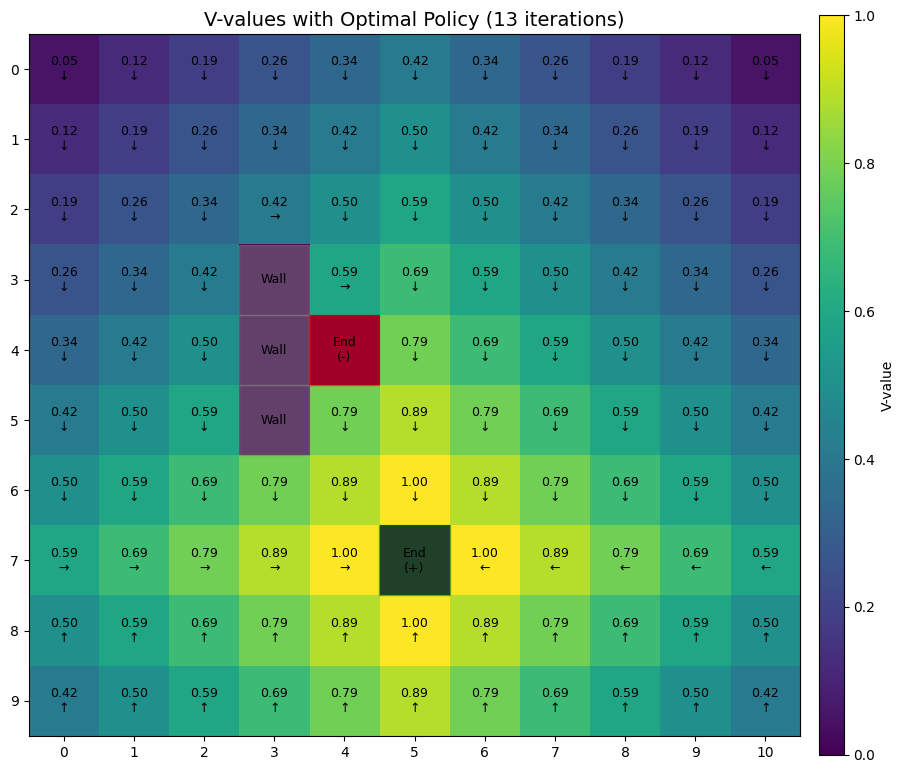

In [53]:
_, ax = plt.subplots(figsize=(12, 12))
plot_v_values(env, ax, V, optimal_policy=optimal_policy_indices, iteration_label=f'{V_iteration} iterations')
plt.show()

### Animated V-values

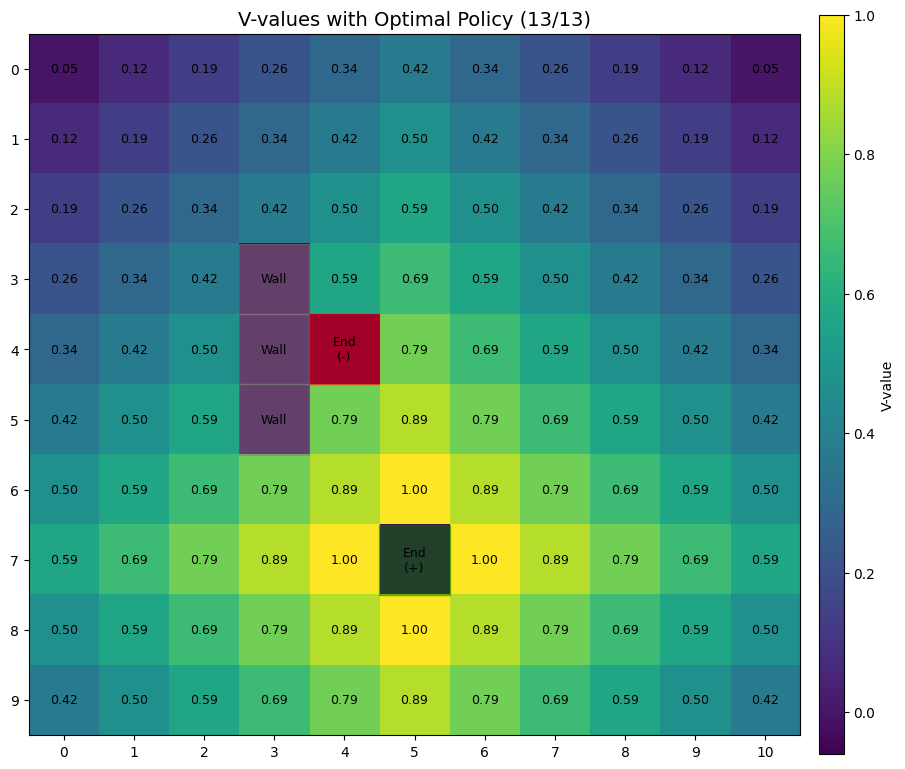

In [54]:
animated_visualization(env, V_history, plot_v_values, V_iteration, 'test_v_values_animation.gif', fig_size=(12, 12))

### Q-values with Optimal Policy

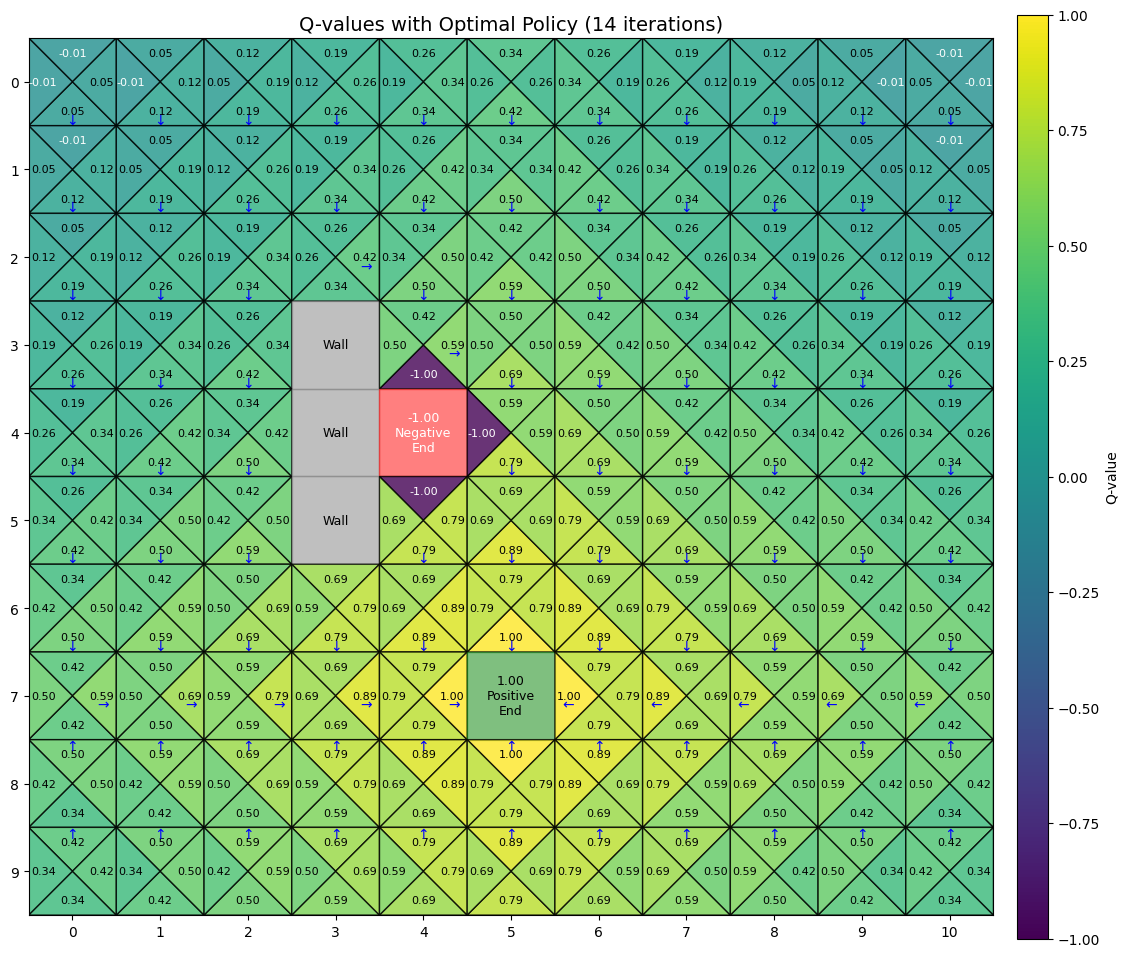

In [55]:
_, ax = plt.subplots(figsize=(15, 15))
plot_q_values(env, ax, Q, optimal_policy=optimal_policy_indices, iteration_label=f'{Q_iteration} iterations')
plt.show()

### Animated Q-values

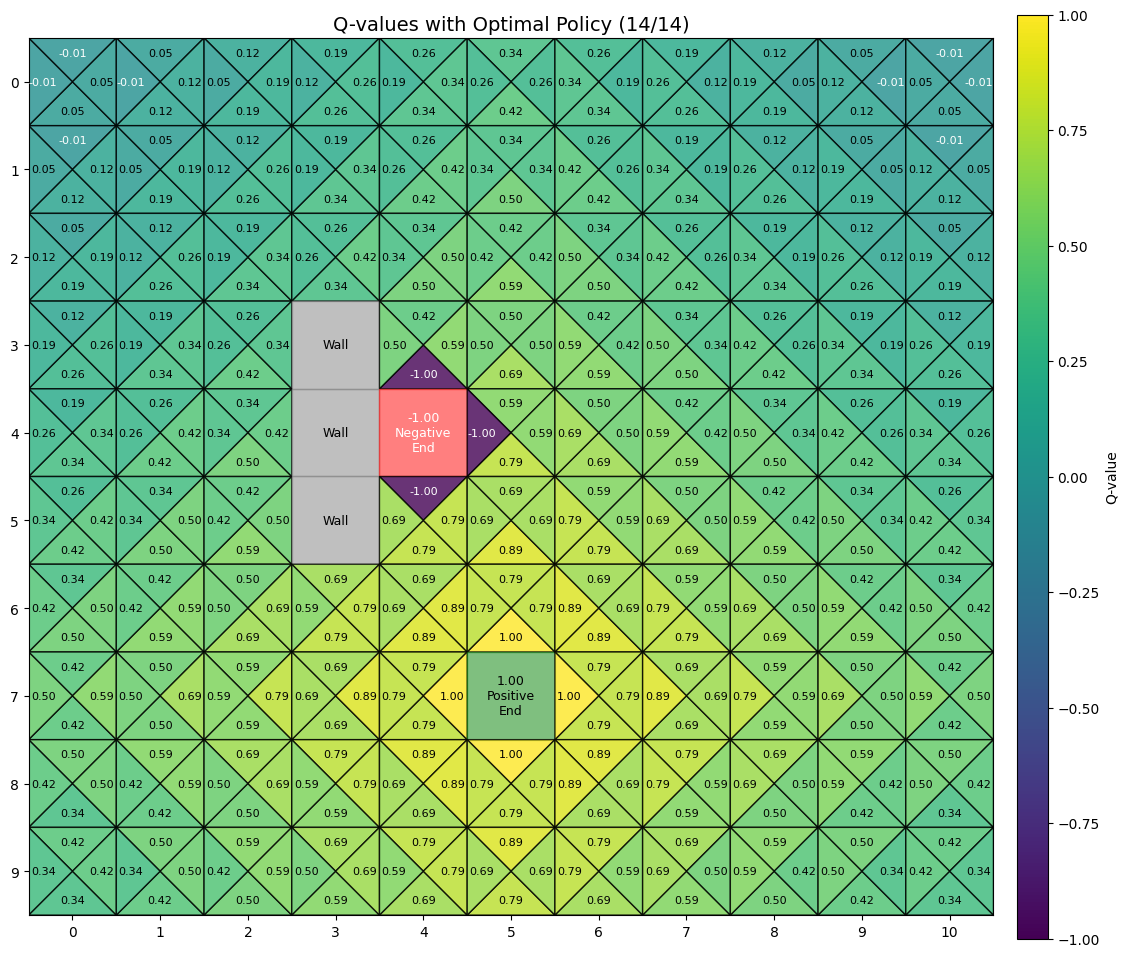

In [56]:
animated_visualization(env, Q_history, plot_q_values, Q_iteration, 'test_q_values_animation.gif', fig_size=(15, 15))